Generating datasets...
Fitting Standard PySINDy (Degree 3 Polynomial)...

Discovered Equations by Standard SINDy:
(x0)' =  0.226 x2 + -0.102 x2^2 + -0.216 x0^2 x1 + -0.138 x0 x1 x2
(x1)' =  0.423 x0^2 x2 + -0.229 x0 x1 x2
(x2)' = -0.117 x1^2 x2
--------------------------------------------------
Rendering 2D Time-Series Comparison...
R2 Score for Train Data: 0.9451016025571105
R2 Score for Train Data: 0.9189200413105527
R2 Score for Train Data: 0.9385163094822996
R2 Score for Test Data: 0.8535887532833171
R2 Score for Test Data: -3.5534301992145627
R2 Score for Test Data: 0.5855568372957808


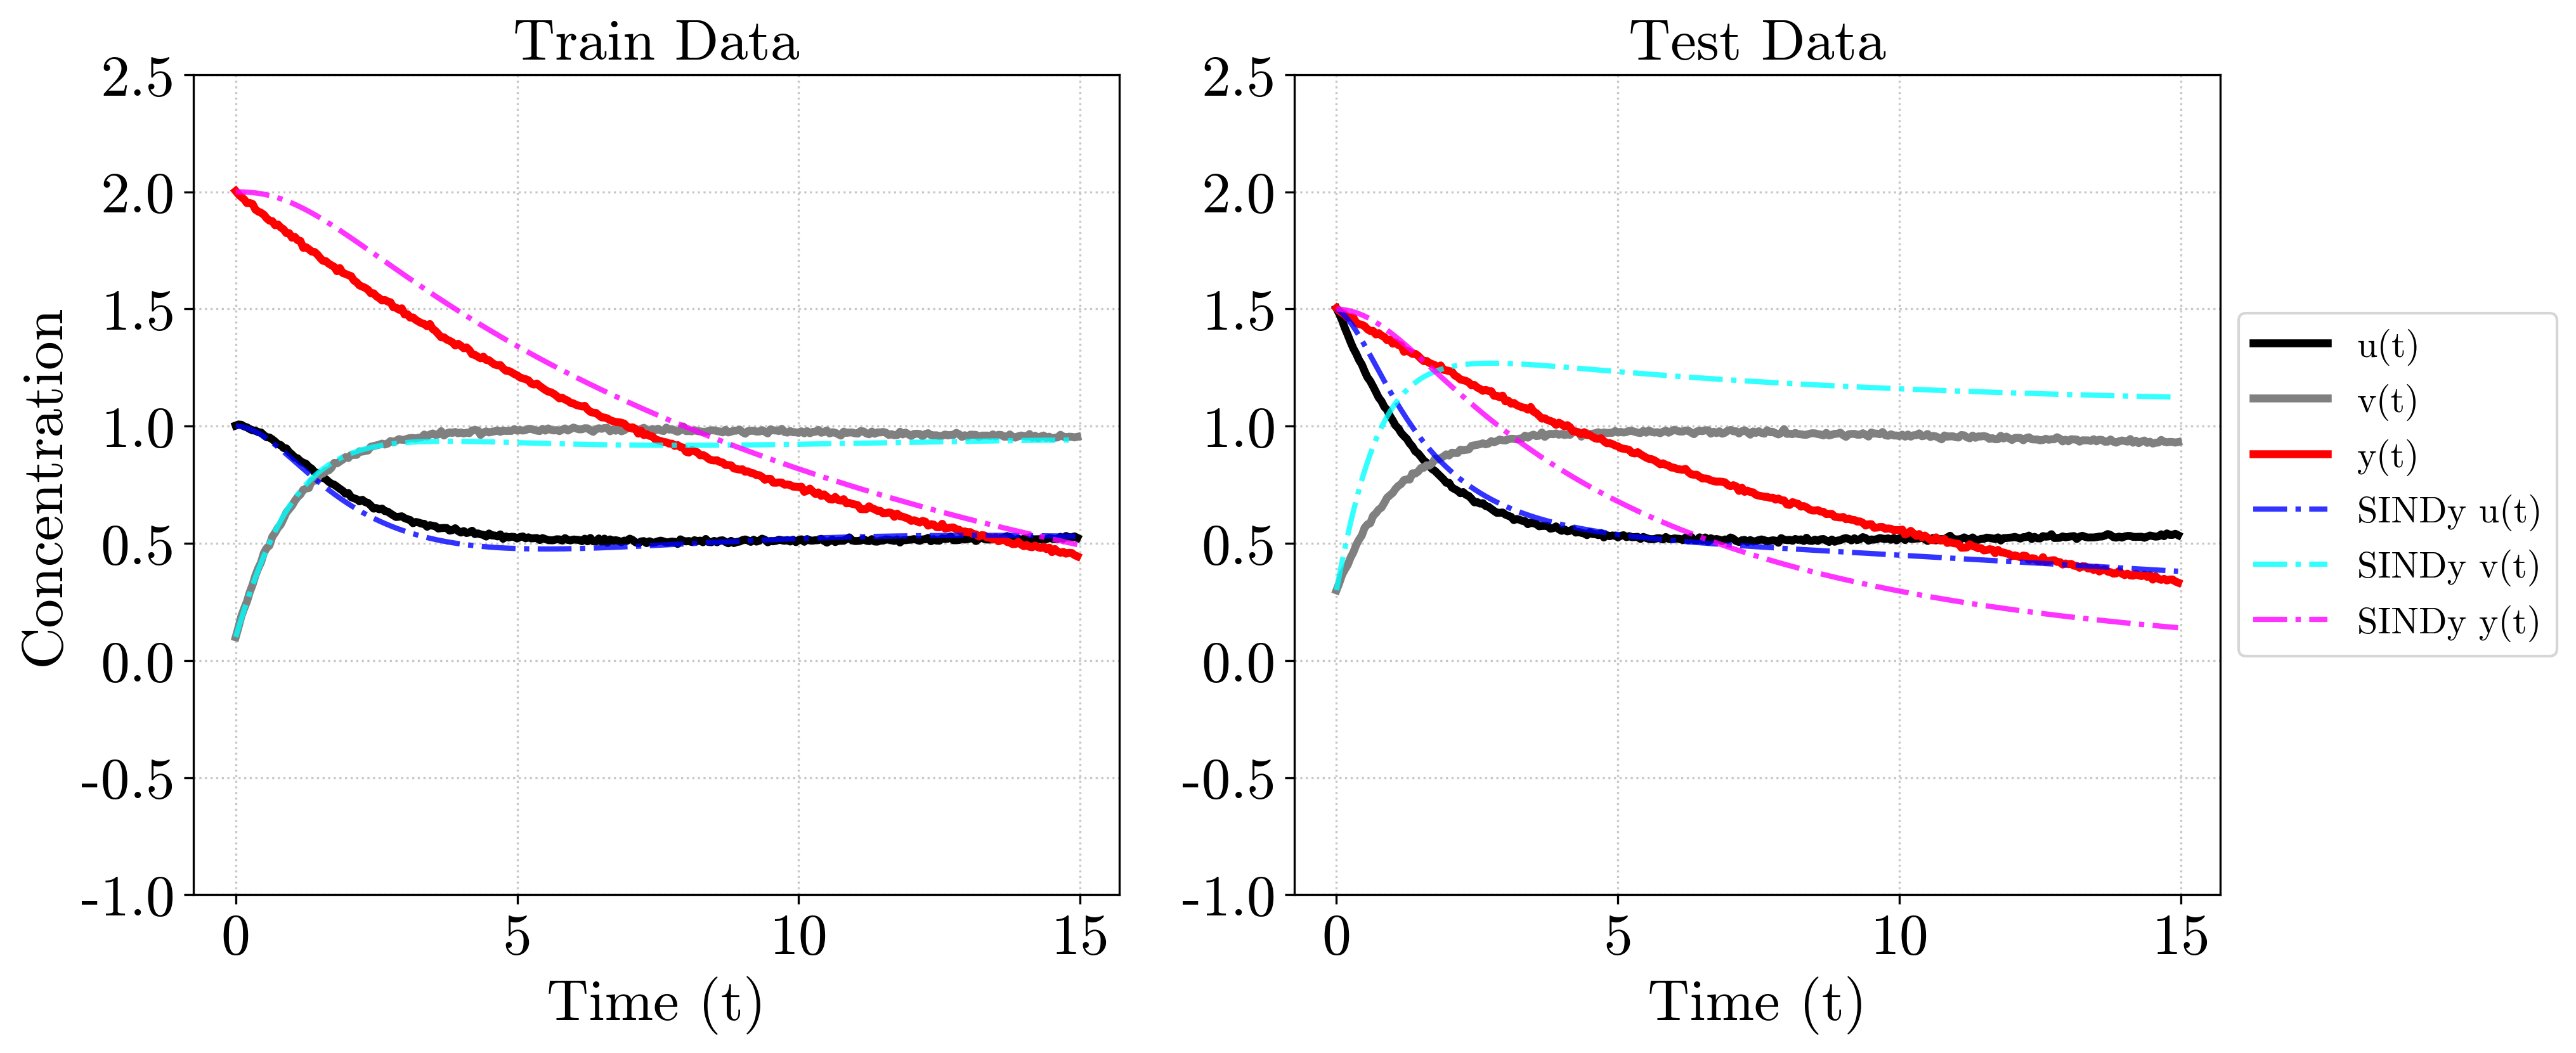

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
import warnings
warnings.filterwarnings("ignore")

def toggle_switch(t, state):
    u, v, y = state
    # u: Repressor 1, v: Repressor 2 (Target), y: Inducer
    du_dt = 1 / (1 + v**2) - u
    dv_dt = 1 / (1 + (u / (1 + y)**2)**2) - v  # The deep nested feature
    dy_dt = -0.1 * y
    return [du_dt, dv_dt, dy_dt]

def generate_dataset(ic, t_span, dt=0.05, noise_level=0.005):
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(toggle_switch, t_span, ic, t_eval=t_eval, method='RK45')

    X_clean = sol.y.T
    np.random.seed(42)
    X_noisy = X_clean + np.random.normal(0, noise_level, X_clean.shape)

    #derivative estimation
    sfd = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 11})
    X_dot = sfd(X_noisy, t_eval)

    return t_eval, X_noisy, X_dot


print("Generating datasets...")
t_train, X_train, X_dot_train = generate_dataset([1.0, 0.1, 2.0], [0, 15])
t_test,  X_test,  X_dot_test  = generate_dataset([1.5, 0.3, 1.5], [0, 15])


print("Fitting Standard PySINDy (Degree 3 Polynomial)...")
'''

Tried giving the custom library to the SINDy model, but it led to instability in the simulation. 
# import pysindy as ps

# lib_funcs = [
#     lambda x: x,                                
#     lambda x: x**2,                             
#     lambda x: 1.0/(1.0 + x**2),                 
#     lambda x: 1.0/(1.0 + x),                    
#     lambda x, y: 1.0/(1.0 + (x/(1.0+y)**2)**2), 
# ]
# lib_names = [
#     lambda x: x,
#     lambda x: f"{x}^2",
#     lambda x: f"1/(1+{x}^2)",
#     lambda x: f"1/(1+{x})",
#     lambda x, y: f"1/(1+({x}/(1+{y})^2)^2)",
# ]
# lib = ps.CustomLibrary(library_functions=lib_funcs, function_names=lib_names,
#                        interaction_only=True, include_bias=True)  

'''
standard_model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=3),
    optimizer=ps.STLSQ(threshold=0.05)
)
standard_model.fit(X_train, x_dot=X_dot_train, t=t_train)

print("\nDiscovered Equations by Standard SINDy:")
standard_model.print()
print("-" * 50)


import matplotlib
matplotlib.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': 'cmr10',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
    'figure.dpi': 300,
})

font = {'weight': 'bold', 'size': 22}
plt.rc('font', **font)

print("Rendering 2D Time-Series Comparison...")
fig1, axes = plt.subplots(1, 2, figsize=(14, 6))
splits = [
    ("Train Data", t_train, X_train, [1.0, 0.1, 2.0]),
    ("Test Data", t_test, X_test, [1.5, 0.3, 1.5]),
]

for ax, (title, t, X_true, ic) in zip(axes, splits):
    
    ax.plot(t, X_true[:, 0], label='u(t)', color='black', lw=3)
    ax.plot(t, X_true[:, 1], label='v(t)', color='gray', lw=3)
    ax.plot(t, X_true[:, 2], label='y(t)', color='red', lw=3)


    # Simulate SINDy Model
    try:
        X_sim = standard_model.simulate(ic, t)
        
        ax.plot(t[:len(X_sim)], X_sim[:, 0], linestyle='-.', color='blue', alpha=0.8, label='SINDy u(t)', lw=2)
        ax.plot(t[:len(X_sim)], X_sim[:, 1], linestyle='-.', color='cyan', alpha=0.8, label='SINDy v(t)', lw=2)
        ax.plot(t[:len(X_sim)], X_sim[:, 2], linestyle='-.', color='magenta', alpha=0.8, label='SINDy y(t)', lw=2)
        from sklearn.metrics import r2_score, root_mean_squared_error
        print(f"R2 Score for {title}: {r2_score(X_true[:, 0], X_sim[:, 0])}")
        print(f"R2 Score for {title}: {r2_score(X_true[:, 1], X_sim[:, 1])}")
        print(f"R2 Score for {title}: {r2_score(X_true[:, 2], X_sim[:, 2])}")


    except Exception as e:
        print(f"SINDy simulation failed on {title} due to instability.")

    ax.set_title(title, fontsize=22)
    ax.set_xlabel('Time (t)', fontsize=22)
    ax.set_ylim(-1.0, 2.5) 
    ax.grid(True, linestyle=':', alpha=0.7)

axes[0].set_ylabel('Concentration', fontsize=22)

axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()


Derivative-estimation quality (SmoothedFiniteDifference vs analytic):

[Train]
   u_dot: R2=0.9113  RMSE=0.0167  MAE=0.0129
   v_dot: R2=0.9847  RMSE=0.0193  MAE=0.0152
   y_dot: R2=0.7525  RMSE=0.0220  MAE=0.0169

[Test]
   u_dot: R2=0.9847  RMSE=0.0167  MAE=0.0130
   v_dot: R2=0.9725  RMSE=0.0193  MAE=0.0152
   y_dot: R2=0.5601  RMSE=0.0220  MAE=0.0169


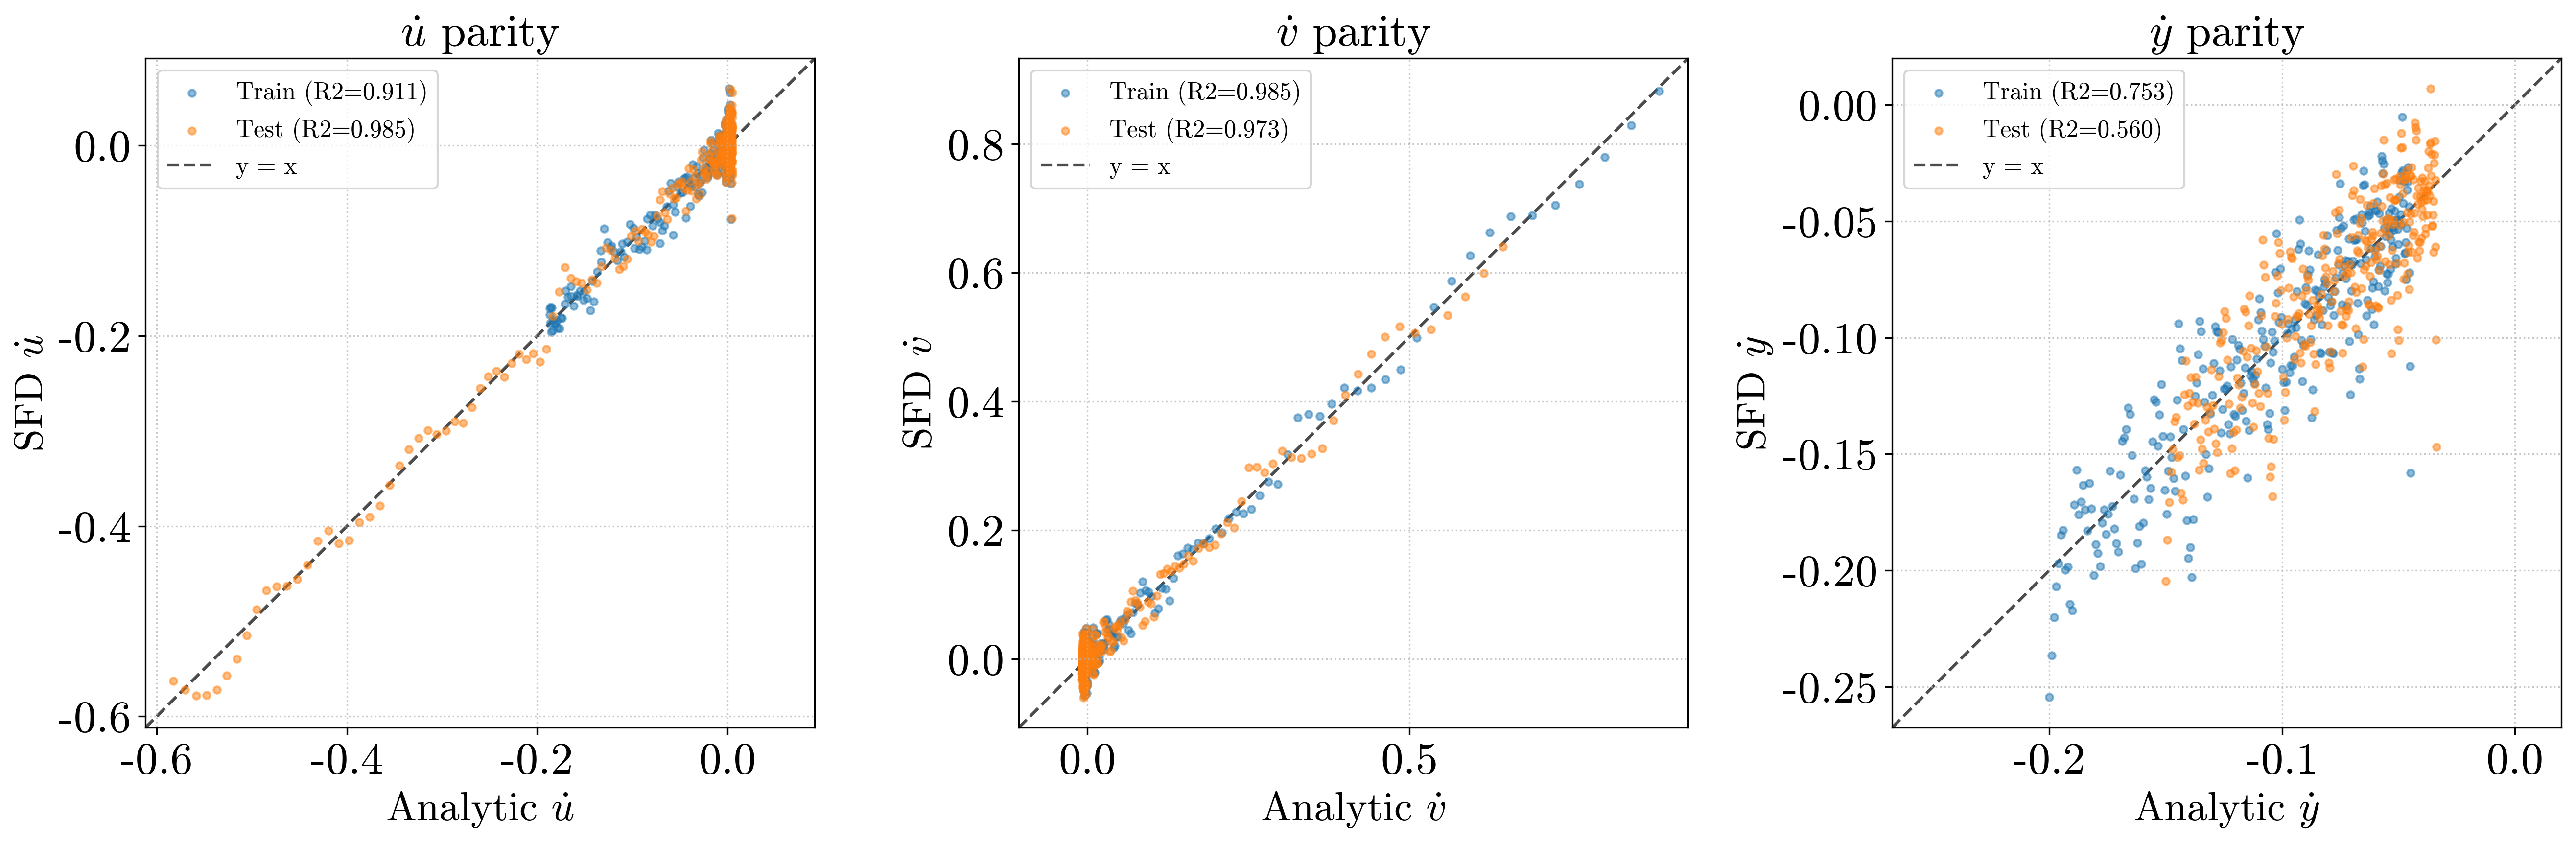

In [ ]:

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def analytic_derivatives(ic, t):
    """Re-integrate the noise-free trajectory and return its analytic dX/dt."""
    X_clean = solve_ivp(toggle_switch, [t[0], t[-1]], ic, t_eval=t, method='RK45').y.T
    return np.array([toggle_switch(0.0, s) for s in X_clean])

parity_splits = [
    ("Train", t_train, X_dot_train, [1.0, 0.1, 2.0], 'tab:blue'),
    ("Test",  t_test,  X_dot_test,  [1.5, 0.3, 1.5], 'tab:orange'),
]
var_labels = [r'$\dot{u}$', r'$\dot{v}$', r'$\dot{y}$']

fig_parity, axes = plt.subplots(1, 3, figsize=(18, 6))

print("Derivative-estimation quality (SmoothedFiniteDifference vs analytic):")
for name, t, X_dot_sfd, ic, color in parity_splits:
    X_dot_true = analytic_derivatives(ic, t)
    print(f"\n[{name}]")
    for i, v in enumerate("uvy"):
        true_i, sfd_i = X_dot_true[:, i], X_dot_sfd[:, i]
        r2   = r2_score(true_i, sfd_i)
        rmse = np.sqrt(mean_squared_error(true_i, sfd_i))
        mae  = mean_absolute_error(true_i, sfd_i)
        print(f"   {v}_dot: R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
        axes[i].scatter(true_i, sfd_i, s=12, alpha=0.5, color=color,
                        label=f"{name} (R2={r2:.3f})")


for i, lab in enumerate(var_labels):
    ax = axes[i]
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.7, zorder=0, label='y = x')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel(f'Analytic {lab}', fontsize=20)
    ax.set_ylabel(f'SFD {lab}', fontsize=20)
    ax.set_title(f'{lab} parity', fontsize=22)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()

In [ ]:
import Feature_Space_Construction as fsc

df_toggle_v = pd.DataFrame({
    'target_v_dot': X_dot_train[:, 1],
    'u': X_train[:, 0],
    'v': X_train[:, 1],
    'y': X_train[:, 2],
})

df_toggle_u = pd.DataFrame({
    'target_u_dot': X_dot_train[:, 0],
    'u': X_train[:, 0],
    'v': X_train[:, 1],
    'y': X_train[:, 2],
})

df_toggle_y = pd.DataFrame({
    'target_y_dot': X_dot_train[:, 2],
    'u': X_train[:, 0],
    'v': X_train[:, 1],
    'y': X_train[:, 2],
})

toggle_operators = ['+', '/', '^-1', 'pow(2)', '+1']

from unittest.mock import patch
with patch('builtins.input', return_value='no'):

    rmse_toggle, equation_toggle, r2_toggle, df_sorted_toggle = fsc.feature_space_construction(
        toggle_operators,
        df_toggle_v,
        no_of_operators=None,
        metrics=[0.01, 0.99],
        dimension=3,
        sis_features=20,
        disp=True
    ).feature_space()

df_sorted_toggle['final'] = df_sorted_toggle.apply(fsc.combine_equation, axis=1)

print(df_sorted_toggle[['Equations', 'final', 'Loss', 'Score', 'Complexity']])

df_toggle_test = pd.DataFrame({
    'u': X_test[:, 0],
    'v': X_test[:, 1],
    'y': X_test[:, 2],
})

for eq in df_sorted_toggle.final[1:]:
    p, _ = fsc.evaluate(eq, df_toggle_test)
    from sklearn.metrics import r2_score
    try:
        print("Equation:", eq)
        print("Test R2:", r2_score(X_dot_test[:, 1], p))
        print('*'*40)
    except:
        print('error')

p_v = df_sorted_toggle.final.tolist()[4]

from unittest.mock import patch
with patch('builtins.input', return_value='no'):

    rmse_toggle, equation_toggle, r2_toggle, df_sorted_toggle = fsc.feature_space_construction(
        toggle_operators,
        df_toggle_u,
        no_of_operators=None,
        metrics=[0.01, 0.99],
        dimension=3,
        sis_features=20,
        disp=True
    ).feature_space()

df_sorted_toggle['final'] = df_sorted_toggle.apply(fsc.combine_equation, axis=1)

print(df_sorted_toggle[['Equations', 'final', 'Loss', 'Score', 'Complexity']])

for eq in df_sorted_toggle.final[1:]:
    p, _ = fsc.evaluate(eq, df_toggle_test)
    from sklearn.metrics import r2_score
    try:
        print("Equation:", eq)
        print("Test R2:", r2_score(X_dot_test[:, 0], p))
        print('*'*40)
    except:
        print('error')

p_u = df_sorted_toggle.final.tolist()[4]

from unittest.mock import patch
with patch('builtins.input', return_value='no'):

    rmse_toggle, equation_toggle, r2_toggle, df_sorted_toggle = fsc.feature_space_construction(
        toggle_operators,
        df_toggle_y,
        no_of_operators=None,
        metrics=[0.01, 0.99],
        dimension=3,
        sis_features=20,
        disp=True
    ).feature_space()

df_sorted_toggle['final'] = df_sorted_toggle.apply(fsc.combine_equation, axis=1)

print(df_sorted_toggle[['Equations', 'final', 'Loss', 'Score', 'Complexity']])


for eq in df_sorted_toggle.final[1:]:
    p, _ = fsc.evaluate(eq, df_toggle_test)
    from sklearn.metrics import r2_score
    try:
        print("Equation:", eq)
        print("Test R2:", r2_score(X_dot_test[:, 2], p))
        print('*'*40)
    except:
        print('error')

p_y = df_sorted_toggle.final.tolist()[3]

torch.Size([300, 21]) torch.Size([21, 2]) torch.Size([21, 1]) 21
****************************** Initial Feature Expansion Completed with feature space size:  21 *********************************************** 

**************************************** Time taken to create the space is::: 0.004101276397705078  Seconds ********************************************

['y', '(y+1)', '(y)**2', '(u+y)', '(u)**2', '(v/u)', '((u)**-1)', '(v/y)', 'u', '(u+1)', '(v)**2', '(v+1)', 'v', '(v+y)', '((y)**-1)', '(u+v)', '(y/v)', '(y/u)', '(u/v)', '(u/y)']
shape of the screened features:: 23
************************************ 2 Feature Expansion Completed with feature space size::: 851  *********************************************************** 

****************************************** Time taken to create the space is::: 1.7186639308929443  Seconds *************************************************** 


['((y)**2/((y)**-1))', '((u+y)/((y)**-1))', '((y)**2+u)', '(u+(y)**2)', '((y)**2+(u+1))', '((y)

Rendering 2D Time-Series Comparison (SyMANTIC, integrated)...
[Train Data] DERIVATIVE R2  -> u_dot=0.9137  v_dot=0.9839  y_dot=0.8070
[Train Data] STATE R2 (traj) -> u=0.9987  v=0.9989  y=0.9998
[Test Data] DERIVATIVE R2  -> u_dot=0.8981  v_dot=0.9615  y_dot=0.6939
[Test Data] STATE R2 (traj) -> u=0.9794  v=0.9918  y=0.9996


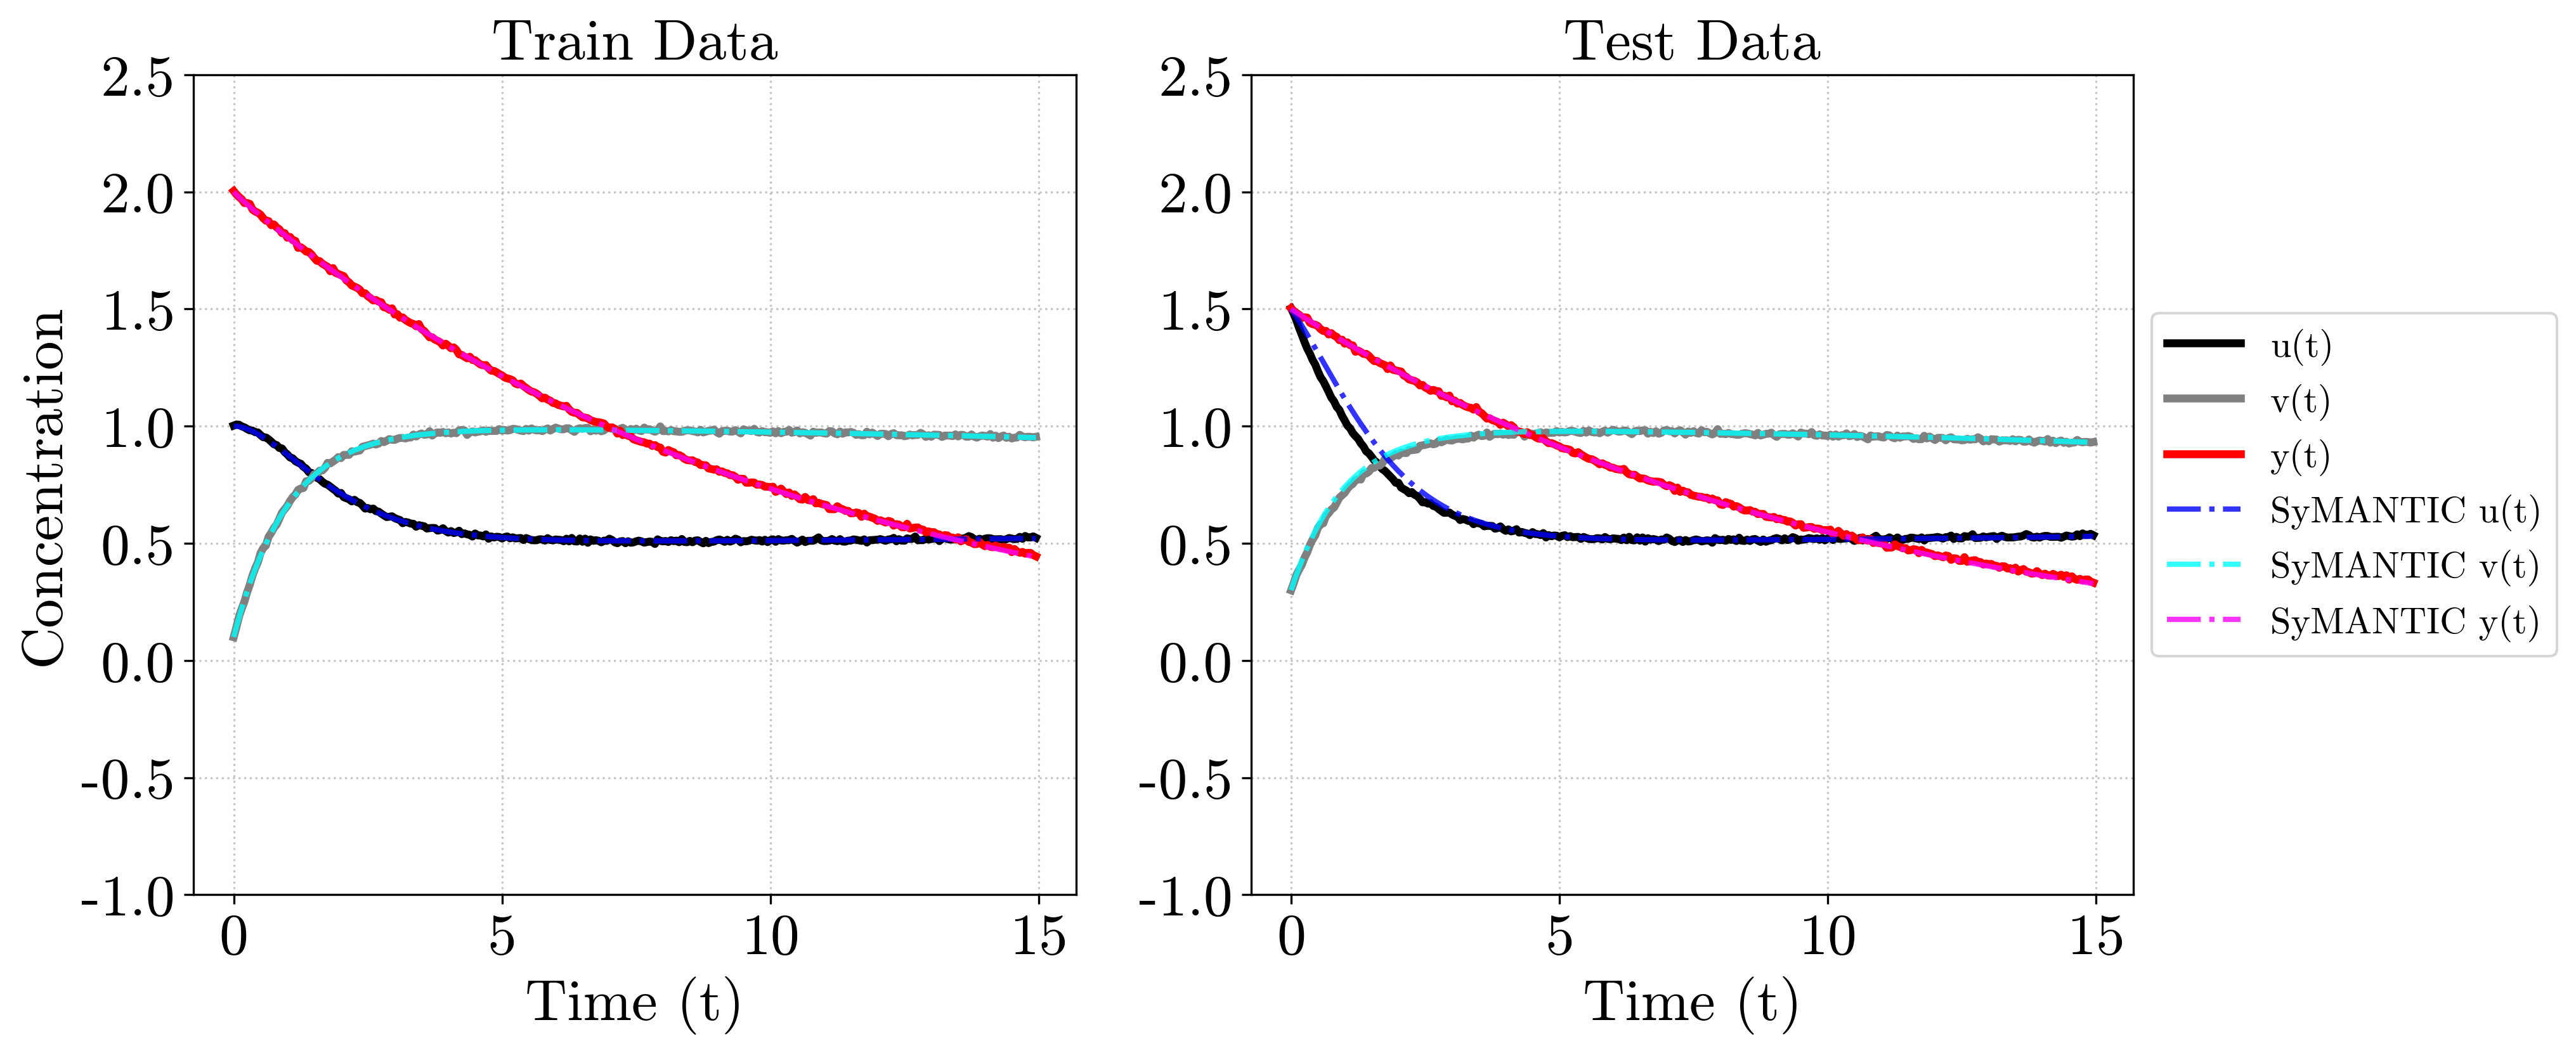

In [ ]:
from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score

def symantic_rhs(t, state):
    u, v, y = state
    pt = pd.DataFrame({'u': [u], 'v': [v], 'y': [y]})
    du, _ = fsc.evaluate(p_u, pt)
    dv, _ = fsc.evaluate(p_v, pt)
    dy, _ = fsc.evaluate(p_y, pt)
    return [float(np.asarray(du).ravel()[0]),
            float(np.asarray(dv).ravel()[0]),
            float(np.asarray(dy).ravel()[0])]

import matplotlib
matplotlib.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': 'cmr10',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
    'figure.dpi': 300,
})

font = {'weight': 'bold', 'size': 22}
plt.rc('font', **font)

print("Rendering 2D Time-Series Comparison (SyMANTIC, integrated)...")
fig2, axes = plt.subplots(1, 2, figsize=(14, 6))
splits = [
    ("Train Data", t_train, X_train, X_dot_train, [1.0, 0.1, 2.0]),
    ("Test Data",  t_test,  X_test,  X_dot_test,  [1.5, 0.3, 1.5]),
]

for ax, (title, t, X_true, X_dot_true, ic) in zip(axes, splits):

    ax.plot(t, X_true[:, 0], label='u(t)', color='black', lw=3)
    ax.plot(t, X_true[:, 1], label='v(t)', color='gray', lw=3)
    ax.plot(t, X_true[:, 2], label='y(t)', color='red', lw=3)

    # --- DERIVATIVE R2 (same metric as cell 2): predicted RHS vs true dX/dt ---
    df_state = pd.DataFrame({'u': X_true[:, 0], 'v': X_true[:, 1], 'y': X_true[:, 2]})
    du_pred, _ = fsc.evaluate(p_u, df_state)
    dv_pred, _ = fsc.evaluate(p_v, df_state)
    dy_pred, _ = fsc.evaluate(p_y, df_state)
    print(f"[{title}] DERIVATIVE R2  -> "
          f"u_dot={r2_score(X_dot_true[:, 0], du_pred):.4f}  "
          f"v_dot={r2_score(X_dot_true[:, 1], dv_pred):.4f}  "
          f"y_dot={r2_score(X_dot_true[:, 2], dy_pred):.4f}")

    # --- STATE R2: integrate the discovered ODE from this split's IC ---
    try:
        sol = solve_ivp(symantic_rhs, [t[0], t[-1]], ic, t_eval=t, method='RK45')
        X_sym = sol.y.T
        n = len(X_sym)

        ax.plot(t[:n], X_sym[:, 0], linestyle='-.', color='blue',    alpha=0.8, label='SyMANTIC u(t)', lw=2)
        ax.plot(t[:n], X_sym[:, 1], linestyle='-.', color='cyan',    alpha=0.8, label='SyMANTIC v(t)', lw=2)
        ax.plot(t[:n], X_sym[:, 2], linestyle='-.', color='magenta', alpha=0.8, label='SyMANTIC y(t)', lw=2)

        print(f"[{title}] STATE R2 (traj) -> "
              f"u={r2_score(X_true[:n, 0], X_sym[:, 0]):.4f}  "
              f"v={r2_score(X_true[:n, 1], X_sym[:, 1]):.4f}  "
              f"y={r2_score(X_true[:n, 2], X_sym[:, 2]):.4f}")

    except Exception as e:
        print(f"SyMANTIC simulation failed on {title}: {e}")

    ax.set_title(title, fontsize=22)
    ax.set_xlabel('Time (t)', fontsize=22)
    ax.set_ylim(-1.0, 2.5)
    ax.grid(True, linestyle=':', alpha=0.7)

axes[0].set_ylabel('Concentration', fontsize=22)
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()

Rendering 2D Time-Series Comparison (PySINDy, integrated)...
[Train Data] DERIVATIVE R2  -> u_dot=0.9156  v_dot=0.9816  y_dot=0.0002
[Train Data] STATE R2 (traj) -> u=0.9451  v=0.9189  y=0.9385
[Test Data] DERIVATIVE R2  -> u_dot=0.5503  v_dot=0.2885  y_dot=0.1694
[Test Data] STATE R2 (traj) -> u=0.8536  v=-3.5534  y=0.5856


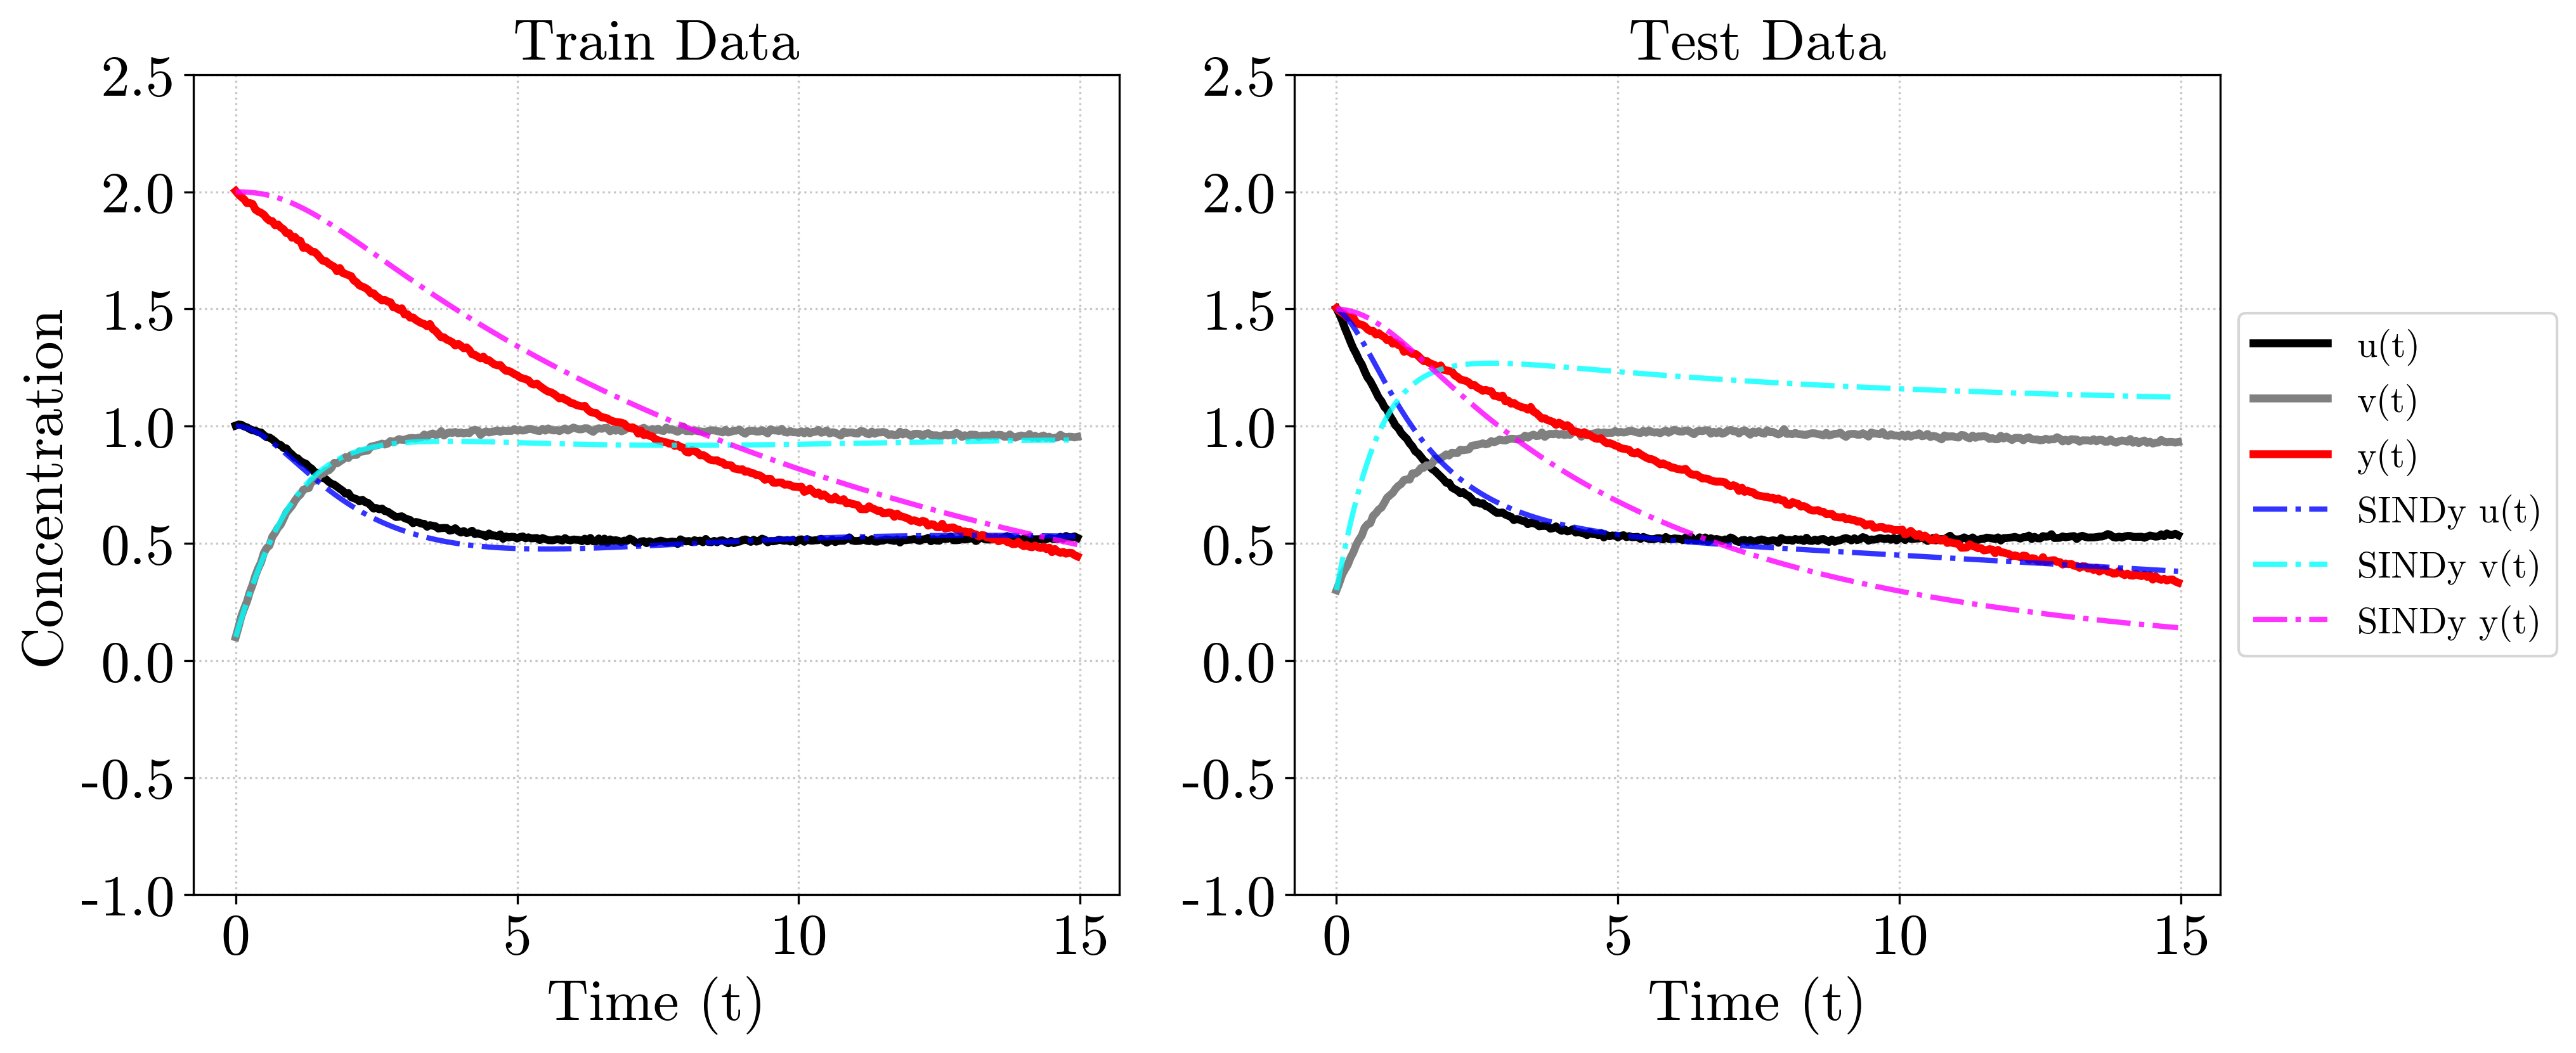

In [22]:
# ---------------------------------------------------------------------------
# PySINDy comparison, mirroring the SyMANTIC cell above. Same two metrics:
#   * DERIVATIVE R2: standard_model.predict(states) vs true dX/dt   (one-step)
#   * STATE R2:      standard_model.simulate(ic, t)  vs true state  (trajectory)
# Run the first cell (which fits `standard_model`) before this one.
# ---------------------------------------------------------------------------
from sklearn.metrics import r2_score

import matplotlib
matplotlib.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': 'cmr10',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
    'figure.dpi': 300,
})

font = {'weight': 'bold', 'size': 22}
plt.rc('font', **font)

print("Rendering 2D Time-Series Comparison (PySINDy, integrated)...")
fig3, axes = plt.subplots(1, 2, figsize=(14, 6))
splits = [
    ("Train Data", t_train, X_train, X_dot_train, [1.0, 0.1, 2.0]),
    ("Test Data",  t_test,  X_test,  X_dot_test,  [1.5, 0.3, 1.5]),
]

for ax, (title, t, X_true, X_dot_true, ic) in zip(axes, splits):

    ax.plot(t, X_true[:, 0], label='u(t)', color='black', lw=3)
    ax.plot(t, X_true[:, 1], label='v(t)', color='gray', lw=3)
    ax.plot(t, X_true[:, 2], label='y(t)', color='red', lw=3)

    # --- DERIVATIVE R2: predicted RHS vs true dX/dt ---
    X_dot_pred = standard_model.predict(X_true)
    print(f"[{title}] DERIVATIVE R2  -> "
          f"u_dot={r2_score(X_dot_true[:, 0], X_dot_pred[:, 0]):.4f}  "
          f"v_dot={r2_score(X_dot_true[:, 1], X_dot_pred[:, 1]):.4f}  "
          f"y_dot={r2_score(X_dot_true[:, 2], X_dot_pred[:, 2]):.4f}")

    # --- STATE R2: integrate (simulate) the model from this split's IC ---
    try:
        X_sim = standard_model.simulate(ic, t)
        n = len(X_sim)

        ax.plot(t[:n], X_sim[:, 0], linestyle='-.', color='blue',    alpha=0.8, label='SINDy u(t)', lw=2)
        ax.plot(t[:n], X_sim[:, 1], linestyle='-.', color='cyan',    alpha=0.8, label='SINDy v(t)', lw=2)
        ax.plot(t[:n], X_sim[:, 2], linestyle='-.', color='magenta', alpha=0.8, label='SINDy y(t)', lw=2)

        print(f"[{title}] STATE R2 (traj) -> "
              f"u={r2_score(X_true[:n, 0], X_sim[:, 0]):.4f}  "
              f"v={r2_score(X_true[:n, 1], X_sim[:, 1]):.4f}  "
              f"y={r2_score(X_true[:n, 2], X_sim[:, 2]):.4f}")

    except Exception as e:
        print(f"PySINDy simulation failed on {title}: {e}")

    ax.set_title(title, fontsize=22)
    ax.set_xlabel('Time (t)', fontsize=22)
    ax.set_ylim(-1.0, 2.5)
    ax.grid(True, linestyle=':', alpha=0.7)

axes[0].set_ylabel('Concentration', fontsize=22)
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()